In [33]:
import os, glob
import matplotlib.pyplot as plt
import numpy as np
from skimage import io
import pandas as pd

In [34]:
%matplotlib widget

In [35]:
from tiled.client import from_profile, from_uri

In [36]:
tiled_client = from_profile('pdf')

In [37]:
mask_dir = '/nsls2/data3/pdf/pdfhack/legacy/processed/xpdacq_data/user_data/config_base/pilatus_PDF/'
masks_pos_flist = ['Mask_pos1_ext_BS.npy', 'Mask_pos2_ext_BS.npy', 'Mask_pos3_ext_BS.npy']
# masks_pos_fn = ['Mask_pos1_ext_BS.npy', 'Mask_pos2_ext_BS.npy', 'Mask_pos3_ext_BS.npy']
m1_path = os.path.join(mask_dir, masks_pos_flist[0])
m2_path = os.path.join(mask_dir, masks_pos_flist[1])
m3_path = os.path.join(mask_dir, masks_pos_flist[2])
use_mask_1= np.load(m1_path)  # This is mask we are applying befor mergin images
use_mask_2 = np.load(m2_path) # This is mask we are applying befor mergin images
use_mask_3 = np.load(m3_path) # This is mask we are applying befor mergin images

In [48]:
uid = '57e3b3d1-530e-4929-9c8b-395332588e56'
run = tiled_client[uid]

In [49]:
my_im1 = np.float32(getattr(run, 'pilatus-1_pos2').read()['pilatus-1_image'].to_numpy()[0][0])
my_im2 = np.float32(getattr(run, 'pilatus-1_pos1').read()['pilatus-1_image'].to_numpy()[0][0])
my_im3 = np.float32(getattr(run, 'pilatus-1_pos0').read()['pilatus-1_image'].to_numpy()[0][0])

In [50]:
osetx = 27
osety = 27

In [51]:
# my_imsum = np.ones((my_im1.shape[0]+int(2*27), my_im2.shape[1]+int(2*27),3))*np.nan

In [52]:
my_imsum = np.ones((my_im1.shape[0]+int(2*osetx), my_im2.shape[1]+int(2*osety),3))*np.nan

my_imsum[osetx:-osetx, osety:-osety, 0] = my_im1
my_imsum[osetx:-osetx, osety:-osety, 0][use_mask_3==1] = np.nan  ##order of mask updated by CHL on 2025/11/03

my_imsum[:-int(2*osetx), :-int(2*osety):, 1] = my_im2
my_imsum[:-int(2*osetx), :-int(2*osety):, 1][use_mask_2==1] = np.nan

my_imsum[int(2*osetx):, int(2*osety):, 2] = my_im3
my_imsum[int(2*osetx):, int(2*osety):, 2][use_mask_1==1] = np.nan  ##order of mask updated by CHL on 2025/11/03

img_mean = np.nanmean(my_imsum, axis=2, dtype=np.float32)

/tmp/ipykernel_3607105/3532039818.py:12: RuntimeWarning: Mean of empty slice
  img_mean = np.nanmean(my_imsum, axis=2, dtype=np.float32)


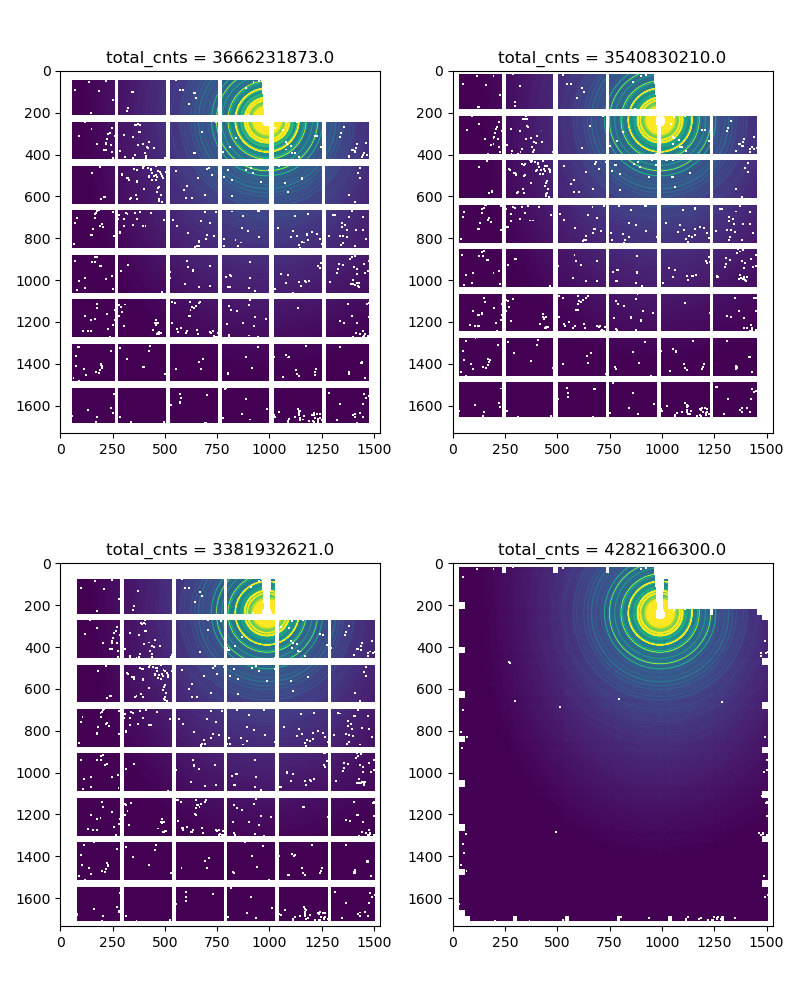

In [53]:
nrows = 2
ncols = int((my_imsum.shape[2]+1)/2)
f1 = plt.figure(figsize=(8, 5*nrows))

for i in range(0, my_imsum.shape[2]+1):
    ax1 = f1.add_subplot(nrows, ncols, i+1)
    
    try:
        img = my_imsum[:, :, i]
    except IndexError:
        img = img_mean
    
    # ax1.imshow(img, vmin=np.nanpercentile(img, 10), vmax=np.nanpercentile(img, 98))
    total_cnts = np.nansum(img)
    ax1.imshow(img, vmin=1000, vmax=9000)
    ax1.set_title(f'{total_cnts = }')
    
f1.tight_layout()

In [54]:
my_imsum2 = np.ones((my_im1.shape[0]+int(2*osetx), my_im2.shape[1]+int(2*osety),3))*np.nan

for i in range(my_imsum.shape[2]):
    my_imsum2[:, :, i] = my_imsum[:, :, i] / np.nanmean(my_imsum[:, :, i])

img_mean2 = np.nanmean(my_imsum2, axis=2, dtype=np.float32)

/tmp/ipykernel_3607105/1359394466.py:6: RuntimeWarning: Mean of empty slice
  img_mean2 = np.nanmean(my_imsum2, axis=2, dtype=np.float32)


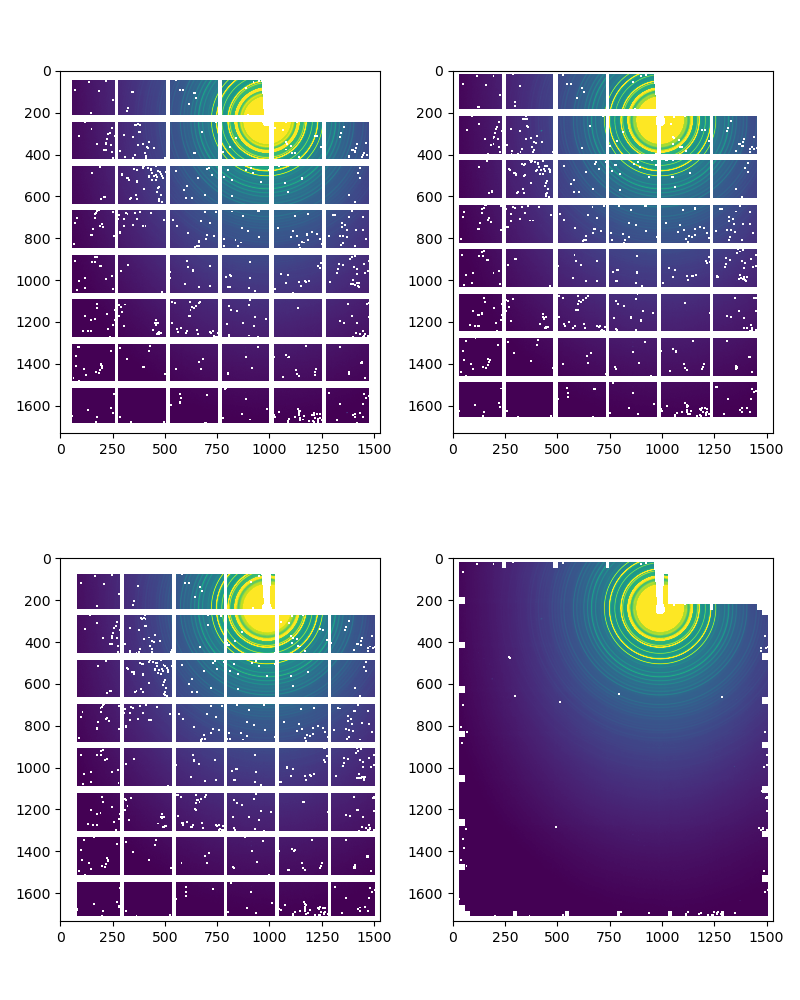

In [55]:
nrows = 2
ncols = int((my_imsum.shape[2]+1)/2)
f2 = plt.figure(figsize=(8, 5*nrows))

for i in range(my_imsum.shape[2]+1):
    ax2 = f2.add_subplot(nrows, ncols, i+1)
    
    try:
        img = my_imsum[:, :, i] / np.nanmean(my_imsum[:, :, i])
    except IndexError:
        img = img_mean2
    
    ax2.imshow(img, vmin=np.nanpercentile(img, 10), vmax=np.nanpercentile(img, 98))
    
f2.tight_layout()

In [56]:
run.start['sample_name']

'MgO_pdf'

In [57]:
img_path = '/nsls2/data3/pdf/pdfhack/legacy/processed/xpdacq_data/user_data/userAnalysis/'
img_fn = f'{run.start["sample_name"]}_normalized_each.tiff'
io.imsave(os.path.join(img_path, img_fn), img_mean2)

In [16]:
ff_path = '/nsls2/data3/pdf/pdfhack/legacy/processed/xpdacq_data/user_data/config_base/flat_field/'
ff_fn = glob.glob(os.path.join(ff_path, '*tiff'))[0]
flat_field = io.imread(ff_fn)

my_im3 = my_im3 / flat_field
my_im2 = my_im2 / flat_field
my_im1 = my_im1 / flat_field

In [17]:
my_imsum3 = np.ones((my_im1.shape[0]+int(2*osetx), my_im2.shape[1]+int(2*osety),3))*np.nan

my_imsum3[osetx:-osetx, osety:-osety, 0] = my_im1
my_imsum3[osetx:-osetx, osety:-osety, 0][use_mask_3==1] = np.nan  ##order of mask updated by CHL on 2025/11/03

my_imsum3[:-int(2*osetx), :-int(2*osety):, 1] = my_im2
my_imsum3[:-int(2*osetx), :-int(2*osety):, 1][use_mask_2==1] = np.nan

my_imsum3[int(2*osetx):, int(2*osety):, 2] = my_im3
my_imsum3[int(2*osetx):, int(2*osety):, 2][use_mask_1==1] = np.nan  ##order of mask updated by CHL on 2025/11/03

img_mean3 = np.nanmean(my_imsum3, axis=2, dtype=np.float32)

/tmp/ipykernel_3607105/938675747.py:12: RuntimeWarning: Mean of empty slice
  img_mean3 = np.nanmean(my_imsum3, axis=2, dtype=np.float32)


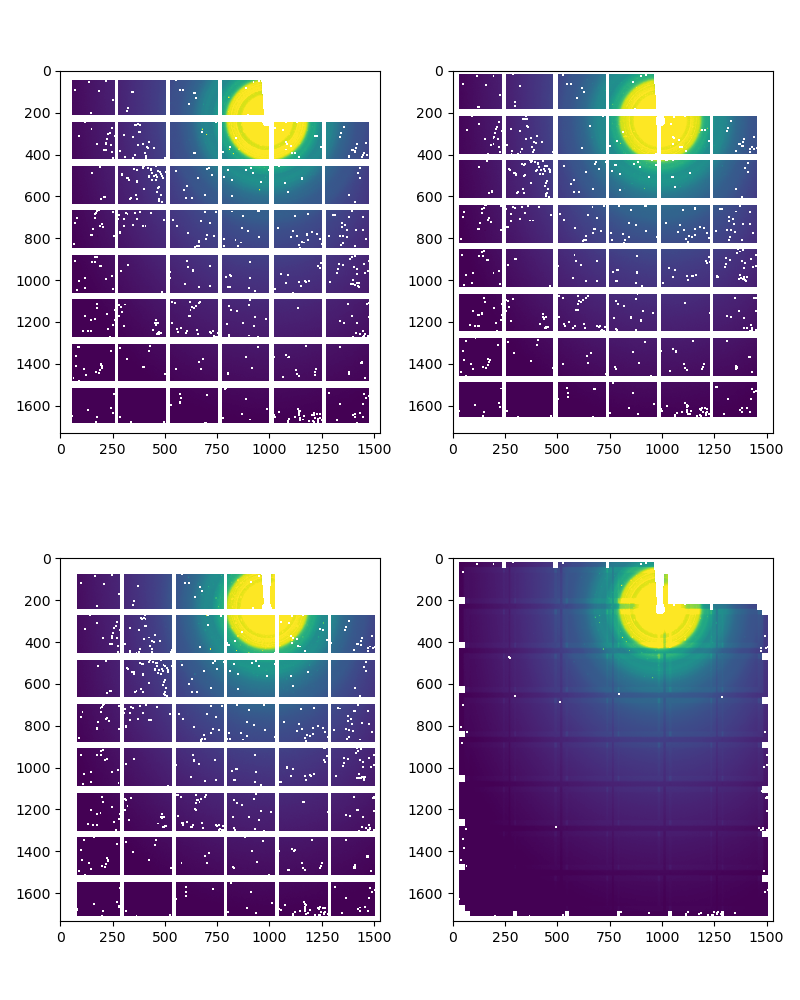

In [18]:
nrows = 2
ncols = int((my_imsum.shape[2]+1)/2)
f3 = plt.figure(figsize=(8, 5*nrows))

for i in range(my_imsum.shape[2]+1):
    ax3 = f3.add_subplot(nrows, ncols, i+1)
    
    try:
        img = my_imsum3[:, :, i]
    except IndexError:
        img = img_mean3
    
    ax3.imshow(img, vmin=np.nanpercentile(img, 10), vmax=np.nanpercentile(img, 98))
    
f3.tight_layout()

In [19]:
my_imsum4 = np.ones((my_im1.shape[0]+int(2*osetx), my_im2.shape[1]+int(2*osety),3))*np.nan

for i in range(my_imsum.shape[2]):
    my_imsum4[:, :, i] = my_imsum3[:, :, i] / np.nanmean(my_imsum3[:, :, i])

img_mean4 = np.nanmean(my_imsum4, axis=2, dtype=np.float32)

/tmp/ipykernel_3607105/3486235666.py:6: RuntimeWarning: Mean of empty slice
  img_mean4 = np.nanmean(my_imsum4, axis=2, dtype=np.float32)


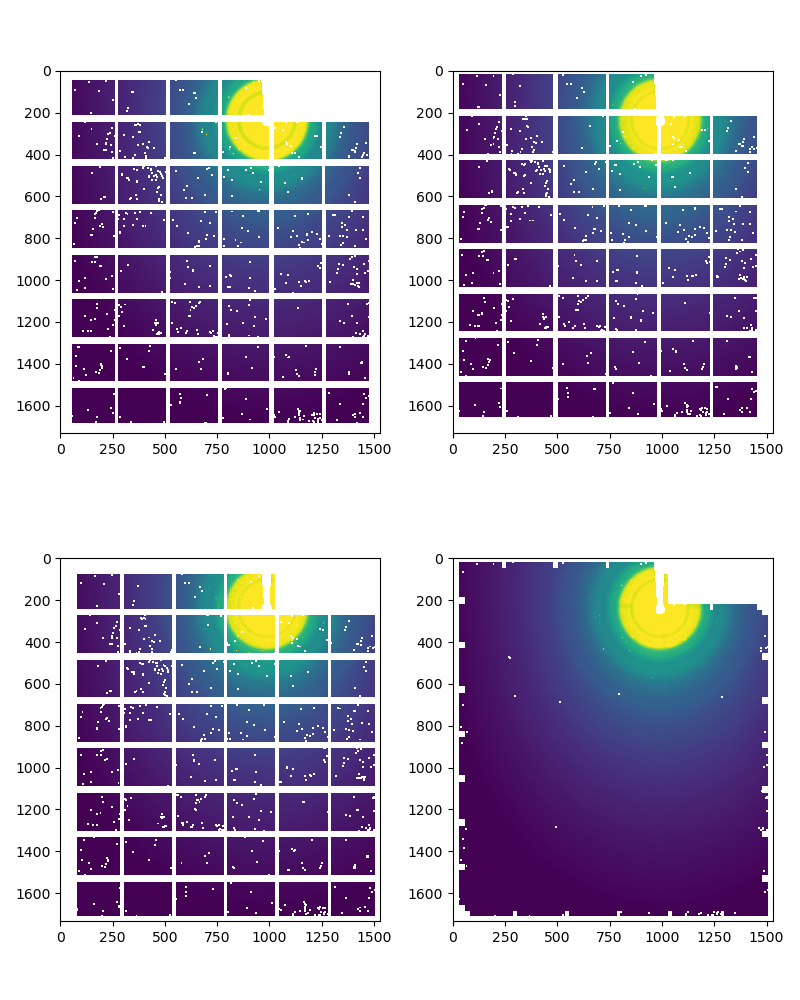

In [20]:
nrows = 2
ncols = int((my_imsum.shape[2]+1)/2)
f4 = plt.figure(figsize=(8, 5*nrows))

for i in range(my_imsum.shape[2]+1):
    ax4 = f4.add_subplot(nrows, ncols, i+1)
    
    try:
        img = my_imsum4[:, :, i] / np.nanmean(my_imsum4[:, :, i])
    except IndexError:
        img = img_mean4
    
    ax4.imshow(img, vmin=np.nanpercentile(img, 10), vmax=np.nanpercentile(img, 98))
    
f4.tight_layout()

In [21]:
# img_path = '/nsls2/data3/pdf/pdfhack/legacy/processed/xpdacq_data/user_data/userAnalysis/'
# img_fn = f'{run.start["sample_name"]}_normalized_each_flat_field.tiff'
# io.imsave(os.path.join(img_path, img_fn), img_mean4)